In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
user = pd.read_csv('../../DATA/User_Profile.csv', encoding='utf-8-sig')
event = pd.read_csv('../../DATA/Event_Log.csv', encoding='utf-8-sig')

print("User_Profile shape:", user.shape)
print("Event_Log shape:", event.shape)

User_Profile shape: (12500, 6)
Event_Log shape: (1757262, 5)


In [3]:
print("[User_Profile]")
display(user.head())

[User_Profile]


,User_ID,가입일자,가입경로,기기,알림수신동의여부,알림수신동의_변경일자
0,U0000001,2025-01-25,오가닉,iOS,True,NaN
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24
2,U0000003,2025-05-14,오가닉,iOS,False,NaN
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaN
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaN


In [4]:
print("[Event_Log]")
display(event.head())

[Event_Log]


,User_ID,Event_Time,Event_Type,Session_ID,알림_유형
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성


In [5]:
print("[ User_Profile 결측치 ]")
display(user.isnull().sum().to_frame('결측치 수'))

[ User_Profile 결측치 ]


,결측치 수
User_ID,0
가입일자,0
가입경로,137
기기,121
알림수신동의여부,116
알림수신동의_변경일자,10524


In [6]:
print("[ Event_Log 결측치 ]")
display(event.isnull().sum().to_frame('결측치 수'))

[ Event_Log 결측치 ]


,결측치 수
User_ID,0
Event_Time,0
Event_Type,26456
Session_ID,241502
알림_유형,1538380


In [7]:
user['가입일자'] = pd.to_datetime(user['가입일자'])
user['알림수신동의_변경일자'] = pd.to_datetime(user['알림수신동의_변경일자'])
event['Event_Time'] = pd.to_datetime(event['Event_Time'])

print("날짜 변환 완료")
display(user.dtypes.to_frame('타입'))

날짜 변환 완료


,타입
User_ID,object
가입일자,datetime64[ns]
가입경로,object
기기,object
알림수신동의여부,object
알림수신동의_변경일자,datetime64[ns]


In [8]:
print("User_Profile 중복 행:", user.duplicated().sum())
print("Event_Log 중복 행:", event.duplicated().sum())
print("User_Profile User_ID 중복:", user['User_ID'].duplicated().sum())

User_Profile 중복 행: 0
Event_Log 중복 행: 0
User_Profile User_ID 중복: 0


In [9]:
print("[ 가입일자 범위 ]")
print("최솟값:", user['가입일자'].min())
print("최댓값:", user['가입일자'].max())

print("\n[ Event_Time 범위 ]")
print("최솟값:", event['Event_Time'].min())
print("최댓값:", event['Event_Time'].max())

[ 가입일자 범위 ]
최솟값: 2025-01-01 00:00:00
최댓값: 2025-05-26 00:00:00

[ Event_Time 범위 ]
최솟값: 2025-01-01 07:00:07
최댓값: 2025-06-30 22:59:51


In [10]:
mask_error = (
    (event['Event_Time'] >= '2025-03-10') &
    (event['Event_Time'] <= '2025-03-14')
)
print("3월 장애 기간 이벤트 수:", event[mask_error].shape[0])
display(event[mask_error].head())

3월 장애 기간 이벤트 수: 17075


,User_ID,Event_Time,Event_Type,Session_ID,알림_유형
331,U0000001,2025-03-10 08:10:53,앱실행,NaN,NaN
332,U0000001,2025-03-10 10:53:33,앱실행,a14e27dad0,NaN
333,U0000001,2025-03-10 10:54:03,운동기록,a14e27dad0,NaN
334,U0000001,2025-03-10 11:27:38,앱실행,a6d44824d1,NaN
335,U0000001,2025-03-10 11:28:08,수면기록,a6d44824d1,NaN


In [11]:
print("[ 가입경로 ]")
display(user['가입경로'].value_counts().to_frame())

print("\n[ 기기 ]")
display(user['기기'].value_counts().to_frame())

print("\n[ 알림수신동의여부 ]")
display(user['알림수신동의여부'].value_counts().to_frame())

[ 가입경로 ]


,count
가입경로,
퍼포먼스광고,6852
오가닉,5511



[ 기기 ]


,count
기기,
iOS,7175
Android,5204



[ 알림수신동의여부 ]


,count
알림수신동의여부,
True,7984
False,4400


In [12]:
print("[ Event_Type ]")
display(event['Event_Type'].value_counts().to_frame())

print("\n[ 알림_유형 ]")
display(event['알림_유형'].value_counts(dropna=False).to_frame())

[ Event_Type ]


,count
Event_Type,
앱실행,728657
수면기록,242978
알림수신,194324
운동기록,131269
마음챙김,130344
식단기록,101366
챌린지참여,96829
챌린지_탐색,78101
알림오픈,21219



[ 알림_유형 ]


,count
알림_유형,
NaN,1538380
리마인드,85830
광고성,78262
챌린지_알림,54790


In [13]:
alarm_events = ['알림수신', '알림오픈']
alarm_mask = event['Event_Type'].isin(alarm_events)

print("알림 이벤트 Session_ID 결측 비율 (높아야 정상):")
print(round(event[alarm_mask]['Session_ID'].isnull().mean() * 100, 2), "%")

print("\n비알림 이벤트 Session_ID 결측 비율 (낮아야 정상):")
print(round(event[~alarm_mask]['Session_ID'].isnull().mean() * 100, 2), "%")

알림 이벤트 Session_ID 결측 비율 (높아야 정상):
100.0 %

비알림 이벤트 Session_ID 결측 비율 (낮아야 정상):
1.68 %


In [14]:
user_ids = set(user['User_ID'])
event_ids = set(event['User_ID'])

print("User_Profile에만 있는 ID:", len(user_ids - event_ids))
print("Event_Log에만 있는 ID:", len(event_ids - user_ids))
print("공통 ID:", len(user_ids & event_ids))

User_Profile에만 있는 ID: 47
Event_Log에만 있는 ID: 0
공통 ID: 12453


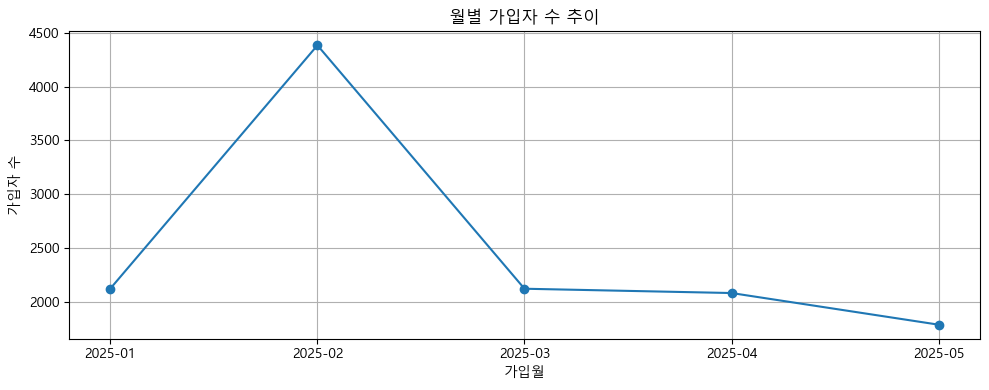

,가입월,가입자수
0,2025-01,2124
1,2025-02,4384
2,2025-03,2122
3,2025-04,2082
4,2025-05,1788


In [15]:
user['가입월'] = user['가입일자'].dt.to_period('M')

monthly_signup = user.groupby('가입월').size().reset_index(name='가입자수')

plt.figure(figsize=(10, 4))
plt.plot(monthly_signup['가입월'].astype(str), monthly_signup['가입자수'], marker='o')
plt.title('월별 가입자 수 추이')
plt.xlabel('가입월')
plt.ylabel('가입자 수')
plt.grid(True)
plt.tight_layout()
plt.show()

display(monthly_signup)

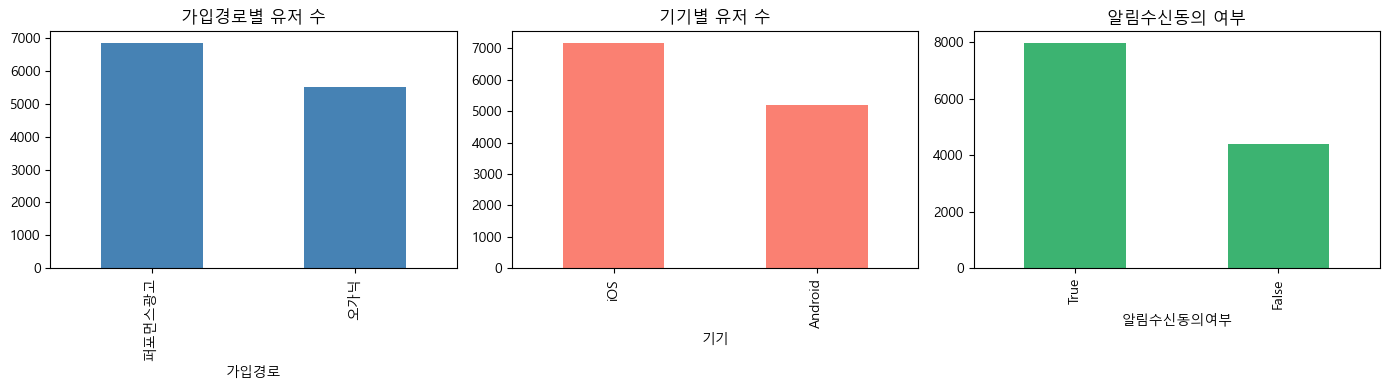

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

user['가입경로'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('가입경로별 유저 수')

user['기기'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('기기별 유저 수')

user['알림수신동의여부'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('알림수신동의 여부')

plt.tight_layout()
plt.show()

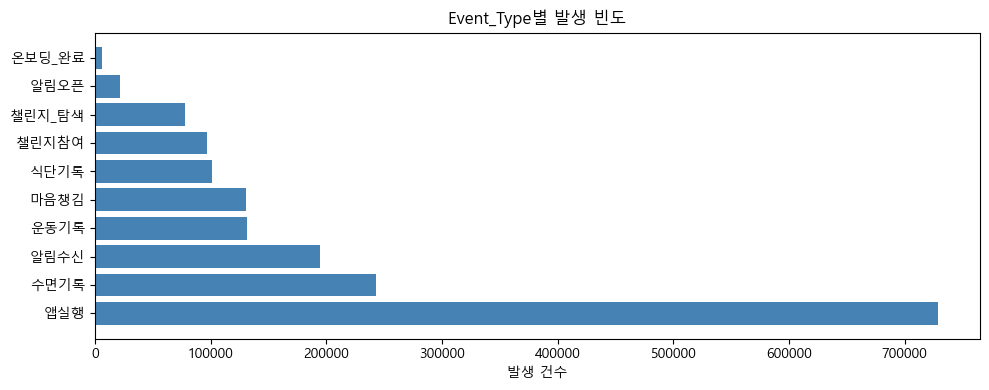

,Event_Type,count
0,앱실행,728657
1,수면기록,242978
2,알림수신,194324
3,운동기록,131269
4,마음챙김,130344
5,식단기록,101366
6,챌린지참여,96829
7,챌린지_탐색,78101
8,알림오픈,21219
9,온보딩_완료,5719


In [17]:
# =============================================
# EDA 3. 이벤트 타입별 발생 빈도
# =============================================
event_counts = event['Event_Type'].value_counts().reset_index()
event_counts.columns = ['Event_Type', 'count']

plt.figure(figsize=(10, 4))
plt.barh(event_counts['Event_Type'], event_counts['count'], color='steelblue')
plt.title('Event_Type별 발생 빈도')
plt.xlabel('발생 건수')
plt.tight_layout()
plt.show()

display(event_counts)

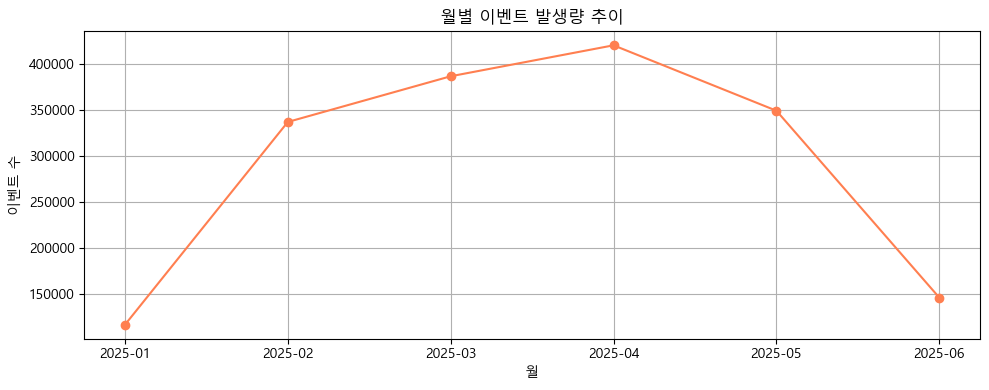

,이벤트월,이벤트수
0,2025-01,117105
1,2025-02,337154
2,2025-03,386739
3,2025-04,420330
4,2025-05,349351
5,2025-06,146583


In [18]:
# =============================================
# EDA 4. 월별 이벤트 발생량 추이
# =============================================
event['이벤트월'] = event['Event_Time'].dt.to_period('M')

monthly_event = event.groupby('이벤트월').size().reset_index(name='이벤트수')

plt.figure(figsize=(10, 4))
plt.plot(monthly_event['이벤트월'].astype(str), monthly_event['이벤트수'], marker='o', color='coral')
plt.title('월별 이벤트 발생량 추이')
plt.xlabel('월')
plt.ylabel('이벤트 수')
plt.grid(True)
plt.tight_layout()
plt.show()

display(monthly_event)

[ 유저별 이벤트 수 기술통계 ]


count    12453.000000
mean       141.111539
std        172.167588
min          1.000000
25%         20.000000
50%         51.000000
75%        219.000000
max        697.000000
Name: 이벤트수, dtype: float64

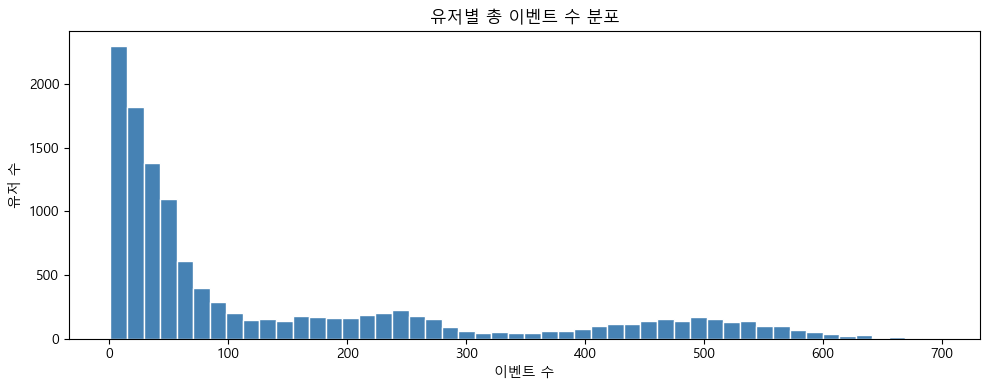

상위 1% 기준값: 592.4799999999996
상위 1% 해당 유저 수: 125명


In [19]:
# =============================================
# EDA 5. 유저별 총 이벤트 수 분포 (극단값 확인)
# =============================================
user_event_count = event.groupby('User_ID').size().reset_index(name='이벤트수')

print("[ 유저별 이벤트 수 기술통계 ]")
display(user_event_count['이벤트수'].describe())

plt.figure(figsize=(10, 4))
plt.hist(user_event_count['이벤트수'], bins=50, color='steelblue', edgecolor='white')
plt.title('유저별 총 이벤트 수 분포')
plt.xlabel('이벤트 수')
plt.ylabel('유저 수')
plt.tight_layout()
plt.show()

top1 = user_event_count['이벤트수'].quantile(0.99)
print(f"상위 1% 기준값: {top1}")
print(f"상위 1% 해당 유저 수: {(user_event_count['이벤트수'] > top1).sum()}명")

In [20]:
# =============================================
# EDA 6. 알림 오픈율 전체 + 유형별
# =============================================
알림수신 = event[event['Event_Type'] == '알림수신'].shape[0]
알림오픈 = event[event['Event_Type'] == '알림오픈'].shape[0]
오픈율 = round(알림오픈 / 알림수신 * 100, 2)

print(f"알림 수신 건수: {알림수신:,}")
print(f"알림 오픈 건수: {알림오픈:,}")
print(f"전체 알림 오픈율: {오픈율}%")

alarm_data = event[event['Event_Type'].isin(['알림수신', '알림오픈'])]
alarm_by_type = alarm_data.groupby(['알림_유형', 'Event_Type']).size().unstack(fill_value=0)
alarm_by_type['오픈율(%)'] = round(alarm_by_type['알림오픈'] / alarm_by_type['알림수신'] * 100, 2)
display(alarm_by_type)

알림 수신 건수: 194,324
알림 오픈 건수: 21,219
전체 알림 오픈율: 10.92%


Event_Type,알림수신,알림오픈,오픈율(%)
알림_유형,,,
광고성,74958,2101,2.80
리마인드,73667,10888,14.78
챌린지_알림,45699,8230,18.01


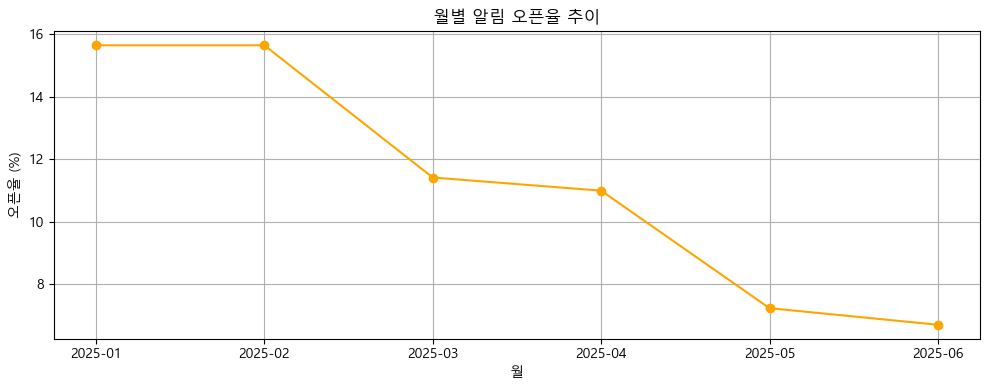

Event_Type,알림수신,알림오픈,오픈율
월,,,
2025-01,10648,1665,15.64
2025-02,32395,5067,15.64
2025-03,43163,4923,11.41
2025-04,49146,5399,10.99
2025-05,40457,2925,7.23
2025-06,18515,1240,6.70


In [21]:
# =============================================
# EDA 7. 월별 알림 오픈율 추이
# =============================================
alarm_monthly = event[event['Event_Type'].isin(['알림수신', '알림오픈'])].copy()
alarm_monthly['월'] = alarm_monthly['Event_Time'].dt.to_period('M')

alarm_pivot = alarm_monthly.groupby(['월', 'Event_Type']).size().unstack(fill_value=0)
alarm_pivot['오픈율'] = round(alarm_pivot['알림오픈'] / alarm_pivot['알림수신'] * 100, 2)

plt.figure(figsize=(10, 4))
plt.plot(alarm_pivot.index.astype(str), alarm_pivot['오픈율'], marker='o', color='orange')
plt.title('월별 알림 오픈율 추이')
plt.xlabel('월')
plt.ylabel('오픈율 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

display(alarm_pivot)

In [22]:
# =============================================
# EDA 8. 온보딩 완료율 + 챌린지 참여율
# =============================================
총유저 = user['User_ID'].nunique()
온보딩완료유저 = event[event['Event_Type'] == '온보딩_완료']['User_ID'].nunique()
챌린지탐색유저 = event[event['Event_Type'] == '챌린지_탐색']['User_ID'].nunique()
챌린지참여유저 = event[event['Event_Type'] == '챌린지참여']['User_ID'].nunique()

print(f"전체 유저: {총유저:,}명")
print(f"온보딩 완료 유저: {온보딩완료유저:,}명 ({round(온보딩완료유저/총유저*100,2)}%)")
print(f"챌린지 탐색 유저: {챌린지탐색유저:,}명 ({round(챌린지탐색유저/총유저*100,2)}%)")
print(f"챌린지 참여 유저: {챌린지참여유저:,}명 ({round(챌린지참여유저/총유저*100,2)}%)")
print(f"탐색→참여 전환율: {round(챌린지참여유저/챌린지탐색유저*100,2)}%")

전체 유저: 12,500명
온보딩 완료 유저: 5,719명 (45.75%)
챌린지 탐색 유저: 9,104명 (72.83%)
챌린지 참여 유저: 9,372명 (74.98%)
탐색→참여 전환율: 102.94%


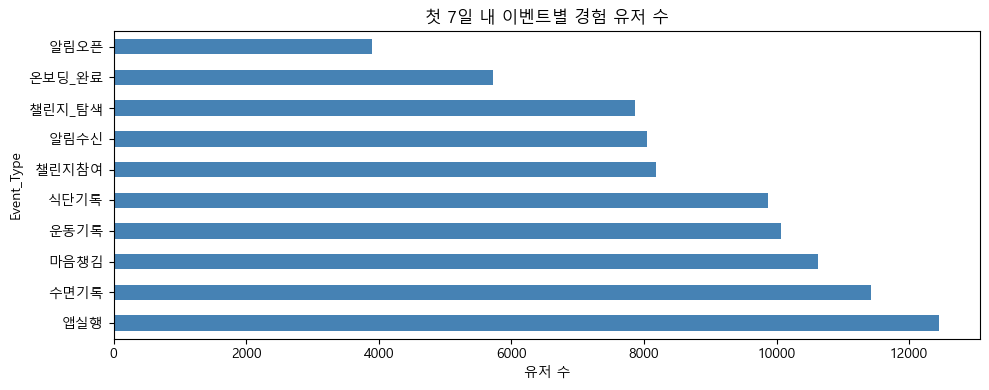

,유저수
Event_Type,
앱실행,12447
수면기록,11424
마음챙김,10631
운동기록,10068
식단기록,9871
챌린지참여,8185
알림수신,8041
챌린지_탐색,7872
온보딩_완료,5719


In [23]:
# =============================================
# EDA 9. 첫 7일 행동 패턴
# (user + event 머지는 여기서만!)
# =============================================
user_join = user[['User_ID', '가입일자']].copy()
event_with_join = event.merge(user_join, on='User_ID', how='left')
event_with_join['가입후일수'] = (
    event_with_join['Event_Time'].dt.date -
    event_with_join['가입일자'].dt.date
).apply(lambda x: x.days)

first7 = event_with_join[event_with_join['가입후일수'].between(0, 6)]

first7_counts = first7.groupby('Event_Type')['User_ID'].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
first7_counts.plot(kind='barh', color='steelblue')
plt.title('첫 7일 내 이벤트별 경험 유저 수')
plt.xlabel('유저 수')
plt.tight_layout()
plt.show()

display(first7_counts.to_frame('유저수'))

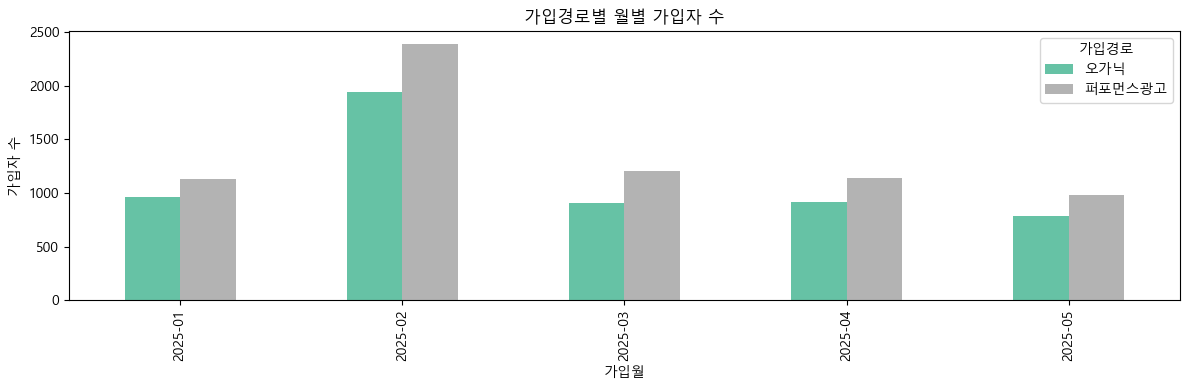

가입경로,오가닉,퍼포먼스광고
가입월,,
2025-01,966,1134
2025-02,1943,2390
2025-03,904,1204
2025-04,916,1142
2025-05,782,982


In [24]:
# =============================================
# EDA 10. 가입경로별 월별 가입자 추이
# =============================================
signup_source = user.groupby(['가입월', '가입경로']).size().unstack(fill_value=0)

signup_source.plot(kind='bar', figsize=(12, 4), colormap='Set2')
plt.title('가입경로별 월별 가입자 수')
plt.xlabel('가입월')
plt.ylabel('가입자 수')
plt.legend(title='가입경로')
plt.tight_layout()
plt.show()

display(signup_source)

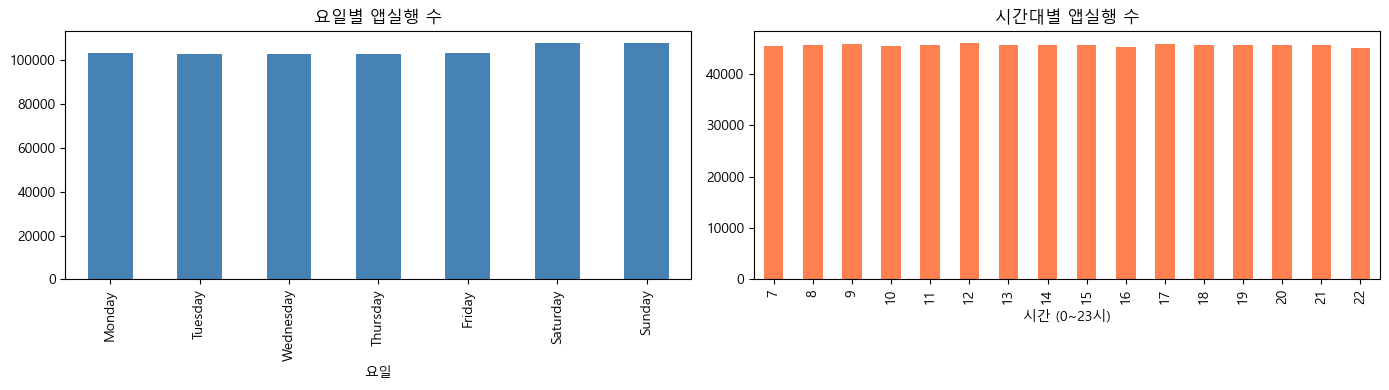

In [25]:
# =============================================
# EDA 11. 요일 / 시간대별 앱실행 패턴
# =============================================
app_open = event[event['Event_Type'] == '앱실행'].copy()
app_open['요일'] = app_open['Event_Time'].dt.day_name()
app_open['시간대'] = app_open['Event_Time'].dt.hour

요일순서 = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
요일별 = app_open['요일'].value_counts().reindex(요일순서)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

요일별.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('요일별 앱실행 수')

app_open['시간대'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('시간대별 앱실행 수')
axes[1].set_xlabel('시간 (0~23시)')

plt.tight_layout()
plt.show()

In [ ]:
# =============================================
# 파생변수 1. 가입 후 첫 행동까지 걸린 시간
# =============================================

# 유저별 첫 이벤트 시간
first_event = event_log.groupby('User_ID')['Event_Time'].min().reset_index()
first_event.columns = ['User_ID', '첫이벤트_시간']

# 가입일시 붙이기
first_event = first_event.merge(user_profile[['User_ID', '가입일자']], on='User_ID', how='left')

# 시간 차이 계산
first_event['첫행동_소요시간_시간'] = (
    first_event['첫이벤트_시간'] - first_event['가입일자']
).dt.total_seconds() / 3600

first_event = first_event[first_event['첫행동_소요시간_시간'] >= 0]

print("[ 첫 행동까지 소요시간 ]")
display(first_event['첫행동_소요시간_시간'].describe())

display(first_event.head())

[ 첫 행동까지 소요시간 ]


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: 첫행동_소요시간_시간, dtype: float64

,User_ID,첫이벤트_시간,가입일자,첫행동_소요시간_시간
